In [1]:
import os
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.clp_zne.utils import summarize_suppression

In [2]:
folder_name = ".\\data\\" + "FakeTorino--Cyclic circuit--12 qubits--Orig noise--CLP ZNE 1 param 2 cycles"

all_evals_ideal = np.load(os.path.join(folder_name, 'evals_ideal.npy'))
all_evals_mitigated = np.load(os.path.join(folder_name, 'evals_mitigated.npy'))
all_evals_noisy = np.load(os.path.join(folder_name, 'evals_noisy.npy'))
all_error_sums = np.load(os.path.join(folder_name, 'error_sums.npy'))

In [3]:
NUM_QUBITS = 12
NUM_CYCLES = 2
INDEX_OF_THE_LEAST_NOISY_CYCLE = 0
INDEX_OF_THE_OTHER_NOISY_CYCLE = 1 # choose any other available for comparison

In [4]:
# Errors on the least noisy qubit cycle
errors_c1 = (all_evals_noisy.reshape(-1, NUM_CYCLES, NUM_QUBITS)[:, INDEX_OF_THE_LEAST_NOISY_CYCLE, :]
             - all_evals_ideal.reshape(-1, 1)).ravel()

# Errors on the other noisy qubit cycle
errors_c2 = (all_evals_noisy.reshape(-1, NUM_CYCLES, NUM_QUBITS)[:, INDEX_OF_THE_OTHER_NOISY_CYCLE, :]
             - all_evals_ideal.reshape(-1, 1)).ravel()

# Errors after mitigation
errors_mit = (all_evals_mitigated - all_evals_ideal).ravel()

In [11]:
# Check the error suppression factors

# Errors for the first layout on the least noisy qubit cycle
errors_baseline = errors_c1.reshape(-1, NUM_QUBITS)[:, 0]

error_suppression_factors = np.abs(errors_baseline)/np.abs(errors_mit)
stats = summarize_suppression(error_suppression_factors)
print("|Error_noisy|/|Error_mitigated| =", stats['formatted'])

|Error_noisy|/|Error_mitigated| = 8.4 [5.1–12.4]


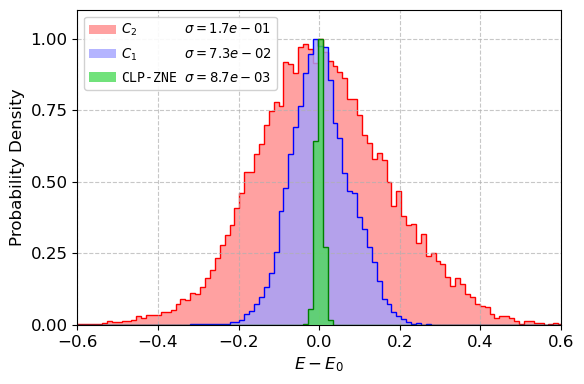

In [12]:
# --- 1. Configuration & Style ---
sns.reset_orig()
font = {'weight': 'normal', 'size': 12}
matplotlib.rc('font', **font)

plt.figure(figsize=(6, 4))

# Plotting parameters
left_crop = 0.6
binwidth = 0.006
bins = np.linspace(-left_crop, left_crop + binwidth, int(left_crop / binwidth))
y_max = 1.0  # Target peak height

# Define datasets in a list
# Order matters for legend and z-order (drawn bottom to top)
datasets = [
    {
        'data': errors_c2,
        'label': r'$C_2$',
        'color_fill': '#ffa1a1',
        'color_line': 'r',
        'alpha': 1.0,
        'zorder': 0
    },
    {
        'data': errors_c1,
        'label': r'$C_1$',
        'color_fill': '#a1a1ff',
        'color_line': 'b',
        'alpha': 0.8,
        'zorder': 1
    },
    {
        'data': errors_mit,
        'label': r'CLP-ZNE',
        'color_fill': '#4ddb5a',
        'color_line': 'g',
        'alpha': 0.8,
        'zorder': 3
    },
]

# --- 2. Processing & Plotting ---
handles = []
labels = []

for i, ds in enumerate(datasets):
    data = ds['data']

    # Calculate Standard Deviation for label
    std_val = np.std(data)
    if i < 2:
        full_label = rf"{ds['label']}      $\sigma = {std_val:.1e}$"
    else:
        full_label = rf"{ds['label']} $\sigma = {std_val:.1e}$"
        
    # Calculate Histogram
    counts, bin_edges = np.histogram(data, bins=bins, density=True)

    # Normalization: Scale so peak is 1
    max_height = np.max(counts)
    if max_height > 0:
        scaled_counts = counts / max_height
    else:
        scaled_counts = counts

    bin_widths = np.diff(bin_edges)

    # Plot Filled Bars
    h_bar = plt.bar(
        bin_edges[:-1], 
        scaled_counts, 
        width=bin_widths, 
        align='edge', 
        alpha=ds['alpha'], 
        color=ds['color_fill'], 
        zorder=ds['zorder'], 
        label=full_label,
        edgecolor=None
    )

    # Plot Outline (Stairs)
    h_line = plt.stairs(
        scaled_counts, 
        bin_edges, 
        color=ds['color_line'], 
        alpha=1.0, 
        zorder=ds['zorder'] + 1 # Ensure line is above fill
    )
    handles.append(h_bar)
    labels.append(full_label)

# Axes
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.ylabel(r'Probability Density')
plt.xlabel('$E-E_0$')
plt.xlim(left=-left_crop, right=left_crop)
plt.ylim(bottom=0, top=1.1)

# Update Ticks to match new normalization (0 to 1)
plt.yticks(np.linspace(0, 1, 5))

# Legend
plt.legend(
    handles, labels, 
    loc='upper left',
    fontsize=12,
    columnspacing=0.8,
    handletextpad=0.4,
    frameon=True,
    framealpha=0.9,
    prop={'family': 'monospace', 'size': 9.5},
    labelspacing=0.6
)

plt.tight_layout()
plt.show()